#### Assignment 3: Iran War Risk and Global Financial Markets

This analysis estimates the sensitivity of global financial variables to Iran War Risk during 2026.

The methodology combines:

1. NLP analysis of Iran-related news
2. Identification through heteroskedasticity
3. Direct NLP regressions as an alternative empirical approach

The sample covers January 1, 2026 through September 18, 2026.

#### Research Question

The main research question is:

> How sensitive are global financial variables to changes in Iran War Risk during 2026?

Iran War Risk is not directly observable. News stories provide information about military escalation, nuclear tensions, sanctions, diplomatic negotiations and ceasefire developments.

The analysis follows the framework in *The Effects of War Risk on U.S. Financial Markets* while using NLP to identify dates with unusually intense Iran-related news.

#### Analysis Structure

The analysis consists of the following stages:

1. Collect Iran-related news from January through September 2026.
2. Clean headlines and RSS descriptions.
3. Apply sentence-transformer embeddings to measure relevance, escalation and de-escalation.
4. Construct a daily Iran War Risk Index.
5. Identify high- and low-news volatility regimes.
6. Estimate market sensitivities through heteroskedasticity.
7. Estimate direct NLP regressions as an alternative method.
8. Compare the results and evaluate methodological limitations.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

news = pd.read_csv(
    ROOT / "data/processed/iran_news_scored.csv"
)

daily_risk = pd.read_csv(
    ROOT / "data/processed/daily_iran_war_risk.csv",
    parse_dates=["market_date"],
)

estimation_sample = pd.read_csv(
    ROOT / "data/processed/estimation_sample.csv",
    parse_dates=["date"],
)

market_changes = pd.read_csv(
    ROOT / "data/processed/market_changes.csv",
    parse_dates=["date"],
)

table_1 = pd.read_csv(
    ROOT / "outputs/tables/table1_high_and_low_news_regimes.csv"
)

table_2 = pd.read_csv(
    ROOT / "outputs/tables/table2_estimated_market_effects.csv"
)

table_3 = pd.read_csv(
    ROOT / "outputs/tables/table3_variance_explained.csv"
)

table_4 = pd.read_csv(
    ROOT / "outputs/tables/direct_nlp_regressions.csv"
)

variance_diagnostics = pd.read_csv(
    ROOT / "outputs/tables/variance_regime_diagnostics.csv"
)

appendix_daily = pd.read_csv(
    ROOT / "outputs/tables/appendix_all_daily_war_risk.csv"
)

print("All final datasets and tables loaded successfully.")

All final datasets and tables loaded successfully.


#### Data Coverage

In [2]:
coverage = pd.DataFrame(
    {
        "Dataset": [
            "Clean news articles",
            "Daily news dates",
            "Common market dates",
            "High-news regime",
            "Matched low-news regime",
            "Financial variables",
        ],
        "Observations": [
            len(news),
            len(daily_risk),
            len(market_changes),
            (
                estimation_sample["regime"]
                .eq("high")
                .sum()
            ),
            (
                estimation_sample["regime"]
                .eq("low")
                .sum()
            ),
            len(variance_diagnostics),
        ],
    }
)

coverage

,Dataset,Observations
0,Clean news articles,8472
1,Daily news dates,188
2,Common market dates,181
3,High-news regime,19
4,Matched low-news regime,19
5,Financial variables,11


The news dataset contains 8,472 unique articles from January 1 through September 18, 2026. The daily dataset contains 188 news dates, while 181 dates overlap with available financial-market observations.

The heteroskedasticity estimation uses 19 high-news days and 19 matched low-news days. The direct NLP regressions use nearly the complete set of overlapping market dates.

#### News Collection

News was collected using Google News RSS searches across three categories:

- Military conflict
- Nuclear developments
- Diplomatic negotiations

Searches were conducted in weekly windows to obtain historical coverage across the complete sample.

Google News limits each RSS result set. Therefore, the article corpus should be interpreted as a broad and diverse sample of news coverage rather than a complete count of every published article.

The corpus includes Reuters, Al Jazeera, PBS, The New York Times, Iran International, CNBC, BBC, CBS News, The Guardian and AP News, among other sources.

#### NLP Methodology

The sentence-transformer model `all-MiniLM-L6-v2` converts each headline and RSS description into a semantic embedding.

Each article is compared with groups of seed statements representing:

- Iran war relevance
- Military escalation
- Diplomatic de-escalation

For article $$i$$:

$$
EventStrength_i
=
\max
\left(
Escalation_i,
Deescalation_i
\right)
$$

$$
WarNewsIntensity_i
=
Relevance_i
\times
EventStrength_i
$$

The maximum of escalation and de-escalation similarity is used because both types of news can produce large revisions in perceived war risk.

In [3]:
score_columns = [
    "relevance_score",
    "escalation_score",
    "deescalation_score",
    "war_news_intensity",
    "war_risk_direction",
]

news[score_columns].describe().round(4)

,relevance_score,escalation_score,deescalation_score,war_news_intensity,war_risk_direction
count,"8,472.0000","8,472.0000","8,472.0000","8,472.0000","8,472.0000"
mean,0.4954,0.4385,0.4026,0.2313,0.0183
std,0.0834,0.0839,0.0871,0.0724,0.0403
min,0.0083,0.0185,-0.0123,0.0009,-0.1566
25%,0.4477,0.3859,0.3481,0.1826,-0.0075
50%,0.4999,0.4402,0.4017,0.2301,0.0190
75%,0.5518,0.4947,0.4602,0.2795,0.0449
max,0.7665,0.7597,0.7056,0.5367,0.1697


In [4]:
signal_counts = (
    news["dominant_signal"]
    .value_counts()
    .rename_axis("Dominant Signal")
    .reset_index(name="Articles")
)

signal_counts

,Dominant Signal,Articles
0,escalation,5794
1,deescalation,2678


#### Daily Iran War Risk Index

Articles released after 4:00 p.m. Eastern Time are assigned to the following business day. Weekend news is also assigned to the next business day.

The daily index is:

$$
RiskIndex_t
=
0.80
\times
Z
\left(
Top10Intensity_t
\right)
+
0.20
\times
Z
\left(
UncertaintyRate_t
\right)
$$

The top 10 percent of dates are classified as high-news days. These dates represent periods when the amount and intensity of Iran-related information were unusually high.

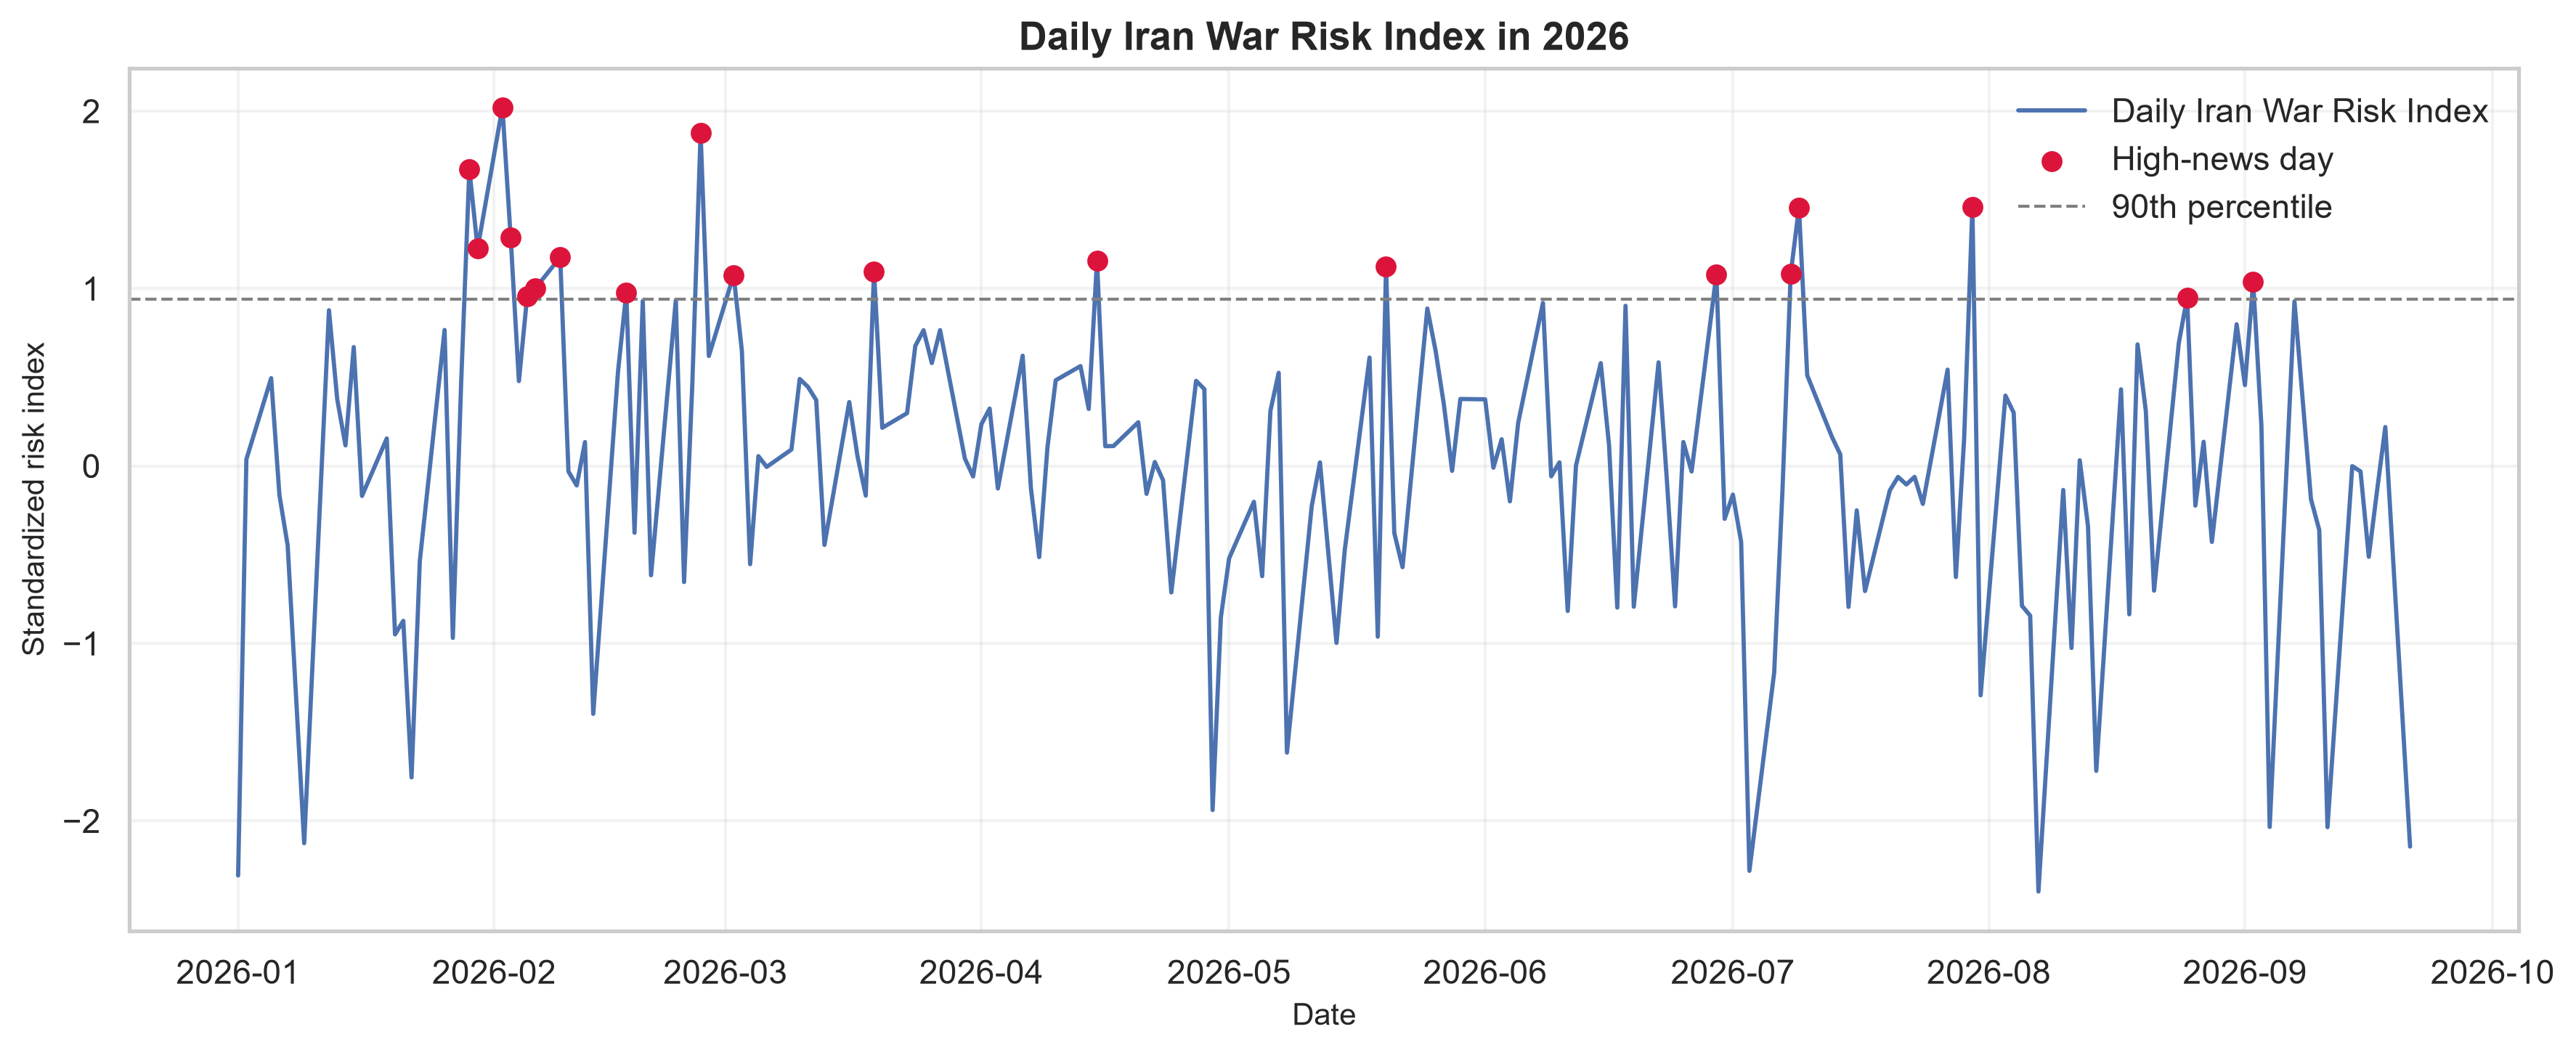

In [5]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/daily_war_risk_index.png"
        )
    )
)

#### Table 1: High- and Low-News Heteroskedasticity Regimes

Table 1 contains all 38 dates used in the heteroskedasticity estimation:

- 19 high-variance Iran news dates
- 19 matched low-variance dates

The low-news observations are selected to be close to the corresponding high-news observations. The median matching distance is two trading days and the maximum distance is nine trading days.

In [6]:
table_1_display = table_1[
    [
        "Date",
        "Regime",
        "NLP Risk Score",
        "News Direction",
        "Article Count",
        "Primary Event",
        "Primary Source",
    ]
].copy()

table_1_display

,Date,Regime,NLP Risk Score,News Direction,Article Count,Primary Event,Primary Source
0,2026-01-29,High variance,1.6704,Escalation,62,Tensions bubble between U.S. and Iran as nuclear talks stall,MS NOW
1,2026-01-30,High variance,1.2245,Escalation,30,US-Iran tensions: The diplomatic scramble to prevent a war,Al Jazeera
2,2026-02-02,High variance,2.0210,Escalation,52,Iran threatens a regional war if US follows through on threat to strike,WBFF
3,2026-02-03,High variance,1.2878,Escalation,42,"Iran risks Trump's ire with new diplomatic demands, provocations",Axios
4,2026-02-05,High variance,0.9561,De-escalation,39,Why Iran–US negotiations must move beyond a single-issue approach to the nuclear problem,Bulletin of the Atomic Scientists
5,2026-02-06,High variance,1.0009,Mixed or unclear,50,"Iran anticipates more negotiations with the US, citing a 'positive atmosphere' during talks in Oman",lemonde.fr
6,2026-02-09,High variance,1.1761,Mixed or unclear,63,"U.S.-Iran Talks Ease Tensions, but Achieve Few Tangible Gains",The Soufan Center
7,2026-02-17,High variance,0.9757,De-escalation,50,Iran and US move forward in talks but tensions linger,Iran International
8,2026-02-26,High variance,1.8755,De-escalation,52,U.S. and Iran wrap up 'most intense' nuclear talks with no deal — more negotiations ahead,CNBC
9,2026-03-02,High variance,1.0748,Escalation,113,"Trump’s war on Iran: grave dangers and, at best, limited benefits",Bulletin of the Atomic Scientists


The complete 188-date daily chronology is retained in:

`outputs/tables/appendix_all_daily_war_risk.csv`

This appendix contains the daily article count, primary event, source, NLP score, uncertainty rate and regime classification.

In [7]:
appendix_summary = pd.DataFrame(
    {
        "Appendix Measure": [
            "Daily rows",
            "First date",
            "Last date",
            "High-variance dates",
            "Matched low-variance dates",
            "Other dates",
        ],
        "Value": [
            len(appendix_daily),
            appendix_daily["Date"].min(),
            appendix_daily["Date"].max(),
            (
                appendix_daily["Regime"]
                .eq("High variance")
                .sum()
            ),
            (
                appendix_daily["Regime"]
                .eq("Matched low variance")
                .sum()
            ),
            (
                appendix_daily["Regime"]
                .eq("Other")
                .sum()
            ),
        ],
    }
)

appendix_summary

,Appendix Measure,Value
0,Daily rows,188
1,First date,2026-01-01
2,Last date,2026-09-21
3,High-variance dates,19
4,Matched low-variance dates,19
5,Other dates,150


#### Financial Variables

The analysis uses:

- 5-year U.S. Treasury yield
- 10-year U.S. Treasury yield
- S&P 500
- Global equity ETF
- Investment-grade corporate bond ETF
- High-yield corporate bond ETF
- Inflation-linked Treasury ETF
- Brent crude oil futures
- Gold futures
- U.S. Dollar Index
- VIX

The original paper uses the 2-year Treasury yield as the reference variable. A reliable 2-year series was unavailable through the selected data source, so the 5-year Treasury yield is used as the reference variable.

Yield changes are measured in percentage points. Prices and market indices are measured using percentage log returns.

#### Identification Through Heteroskedasticity

Let daily changes in financial variables be:

$$
\Delta X_t
=
D z_t + \mu_t
$$

where:

- $$z_t$$ is the unobservable Iran War Risk factor
- $$D$$ contains the sensitivity of financial variables to that factor
- $$\mu_t$$ contains other financial shocks

Let:

$$
\Omega_H
=
Var
\left(
\Delta X_t
\mid H
\right)
$$

and:

$$
\Omega_L
=
Var
\left(
\Delta X_t
\mid L
\right)
$$

The covariance difference is:

$$
\Delta \Omega
=
\Omega_H-\Omega_L
$$

If the principal difference between the two regimes is the variance of Iran War Risk, the change in market covariance identifies the relative market sensitivities.

Using the 5-year Treasury yield as the reference variable:

$$
\hat{d}_j
=
\frac{
Cov_H
\left(
\Delta x_1,\Delta x_j
\right)
-
Cov_L
\left(
\Delta x_1,\Delta x_j
\right)
}{
Var_H
\left(
\Delta x_1
\right)
-
Var_L
\left(
\Delta x_1
\right)
}
$$

The estimated effects are normalized to a war-risk shock associated with a 10-basis-point decline in the 5-year Treasury yield.

#### Variance-Regime Validation

The identification strategy requires the reference-variable variance to be higher during the high-news regime.

The 5-year Treasury yield variance ratio is approximately:

$$
\frac{
Var_H
\left(
\Delta y^{5Y}
\right)
}{
Var_L
\left(
\Delta y^{5Y}
\right)
}
=
1.69
$$

Nine of the eleven financial variables have higher variance on high-news days. Brent oil and gold have the largest variance increases.

In [8]:
variance_display = variance_diagnostics[
    [
        "variable",
        "variance_low",
        "variance_high",
        "variance_difference",
        "variance_ratio",
        "levene_pvalue",
    ]
].copy()

variance_display.round(4)

,variable,variance_low,variance_high,variance_difference,variance_ratio,levene_pvalue
0,d_five_year_yield,0.0014,0.0024,0.0010,1.6883,0.4475
1,d_ten_year_yield,0.0012,0.0017,0.0005,1.4040,0.6709
2,r_sp500,0.4069,0.6506,0.2437,1.5989,0.3926
3,r_global_equity,0.5769,0.7908,0.2139,1.3707,0.4439
4,r_investment_grade_bonds,0.1065,0.0739,-0.0326,0.6940,0.4323
5,r_high_yield_bonds,0.0370,0.0388,0.0018,1.0492,0.6197
6,r_inflation_linked_bonds,0.0407,0.0314,-0.0093,0.7717,0.7180
7,r_brent_oil,3.0477,10.6789,7.6312,3.5040,0.0822
8,r_gold,1.7626,11.9256,10.1630,6.7660,0.0863
9,r_dollar_index,0.1395,0.2064,0.0668,1.4790,0.6901


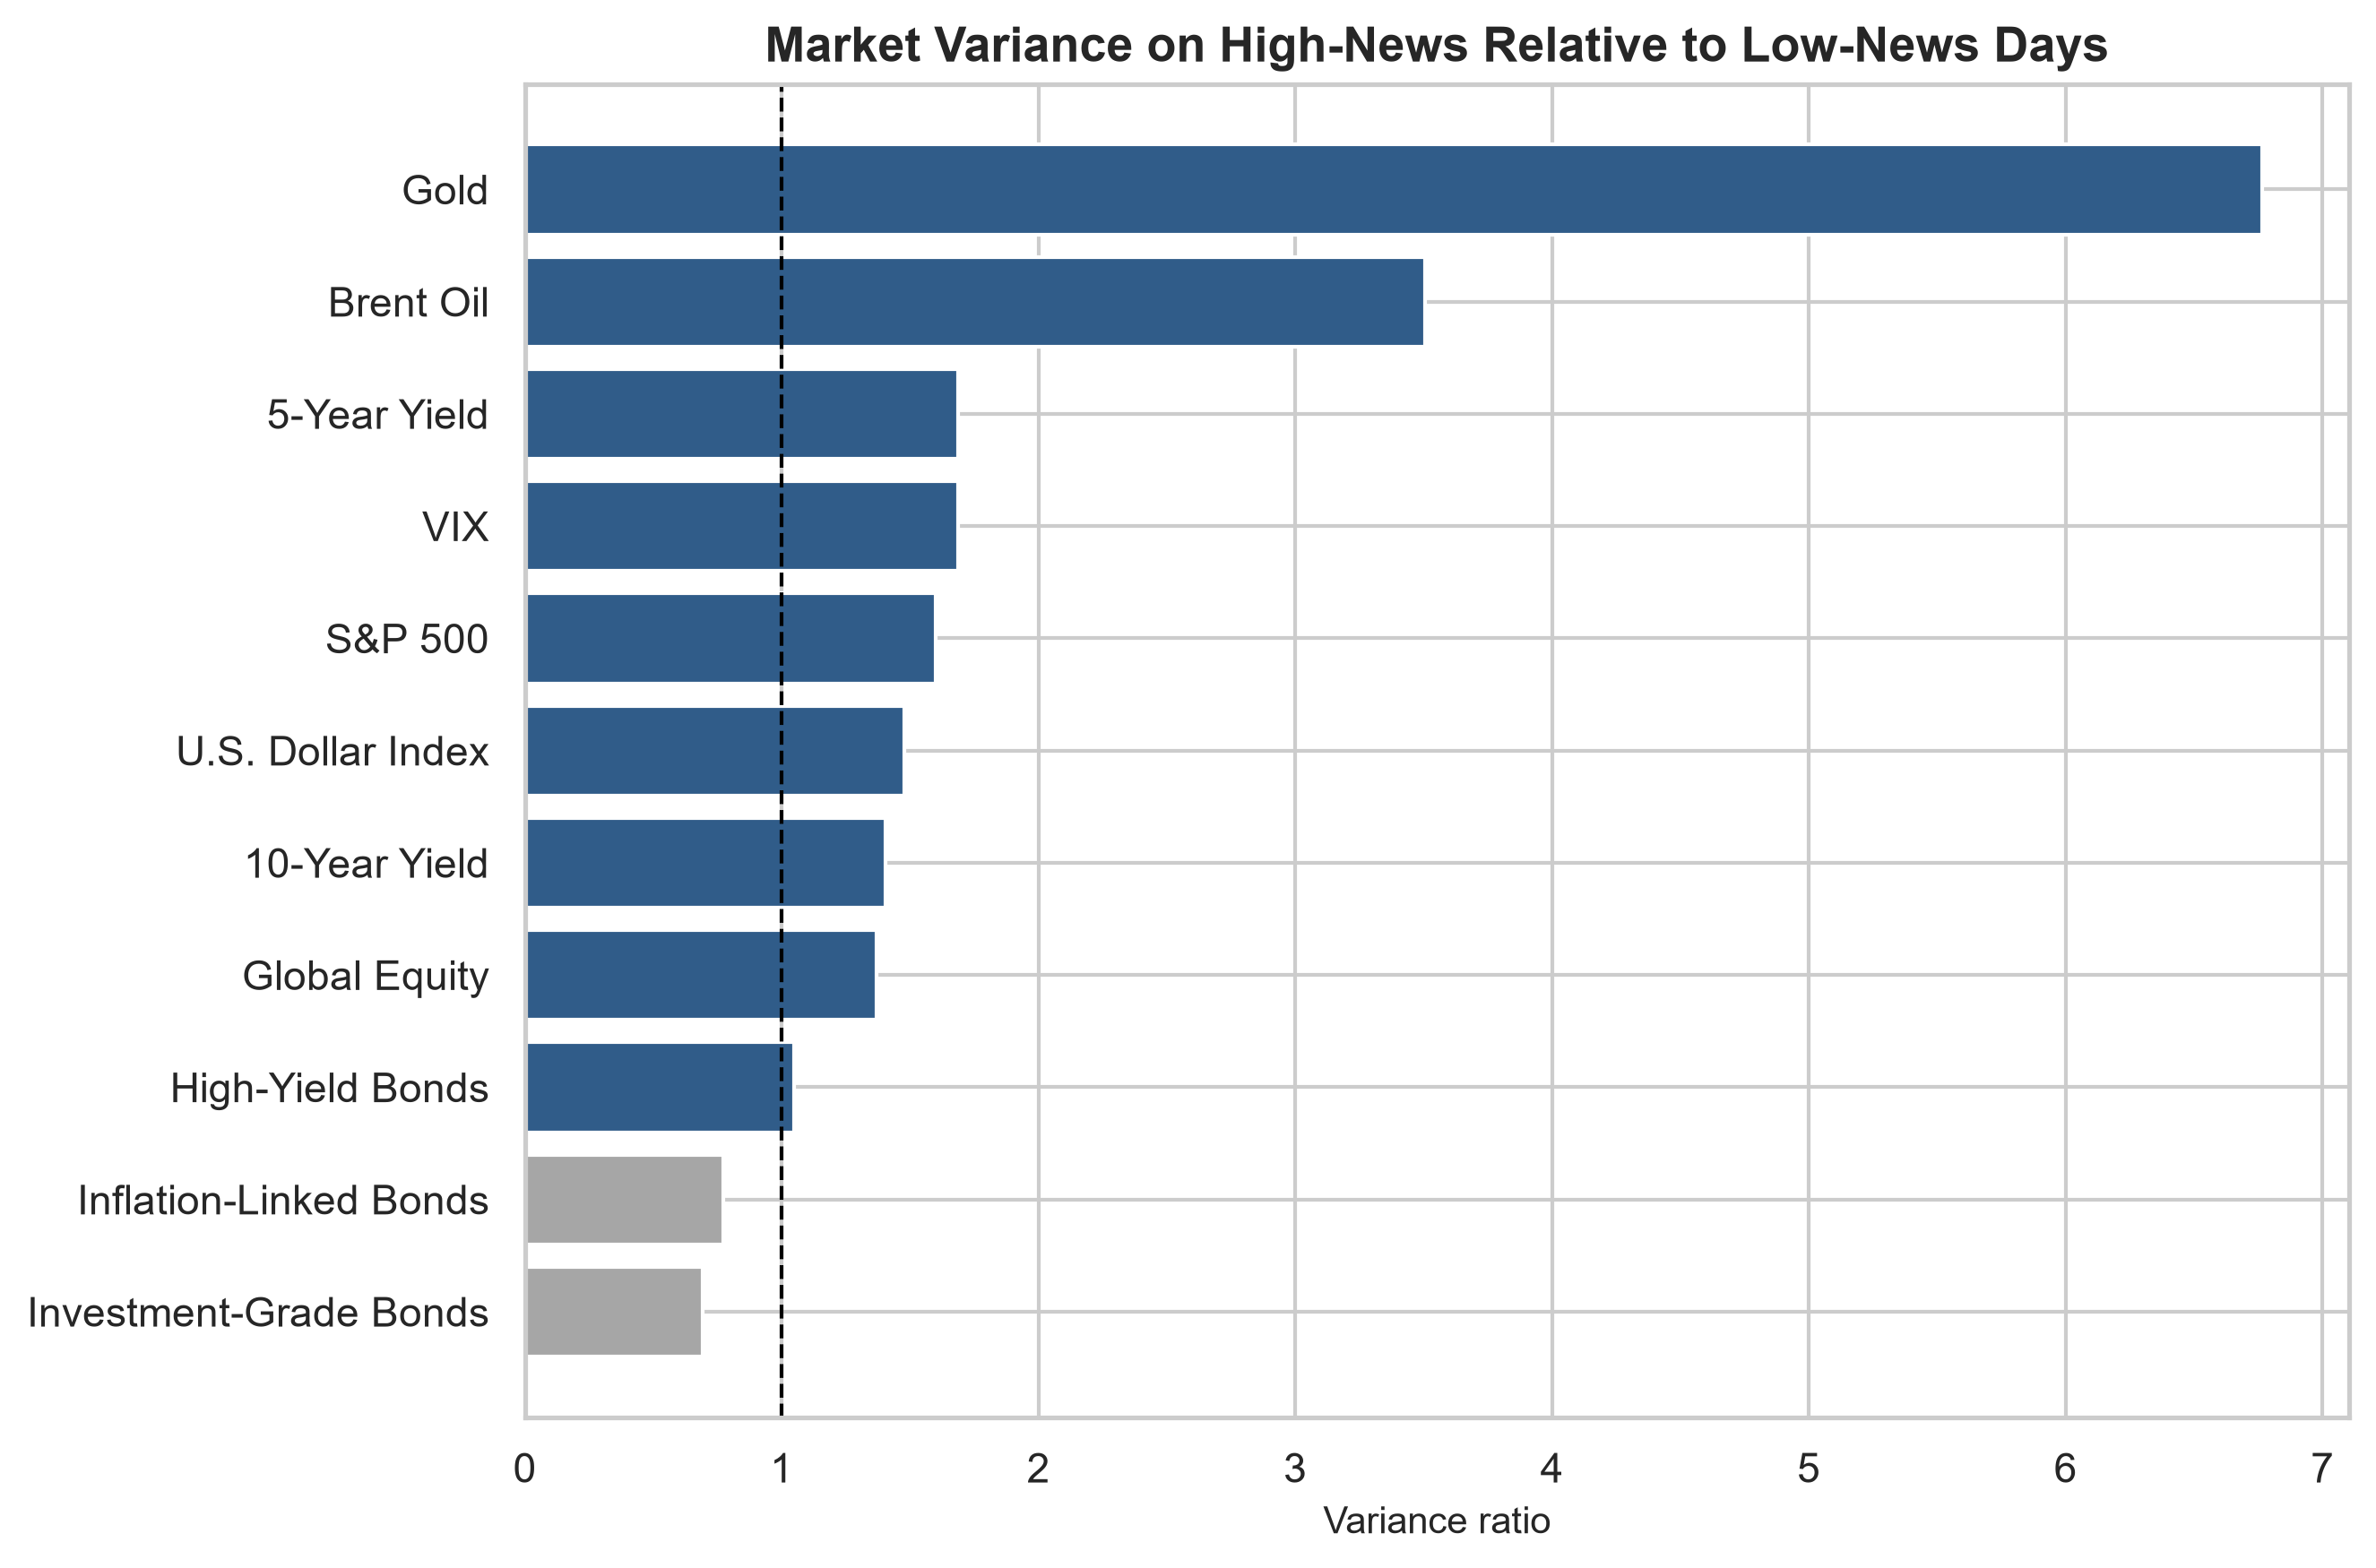

In [9]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/variance_ratios.png"
        )
    )
)

#### Table 2: Estimated Impact of an Increase in Iran War Risk

Table 2 replicates the main structure of the original war-risk paper.

The three estimators use alternative instruments derived from the covariance changes across the high- and low-news regimes. Bootstrap confidence intervals are reported for the combined estimator.

In [10]:
table_2

,Financial Variable,Units,Estimator 1,Estimator 2,Combined IV,95% CI Low,95% CI High,Significant at 5%
0,10-Year Treasury Yield,Basis-point change,-7.0540,-7.1440,-6.9440,-11.8550,-3.6810,True
1,S&P 500,Percent change,-1.0540,-2.3310,-1.4420,-4.2270,1.6700,False
2,Global Equity,Percent change,-1.0940,-1.9720,-1.3510,-3.9380,1.8060,False
3,Investment-Grade Bonds,Percent change,0.0140,-24.2640,0.3440,-0.1160,1.3650,False
4,High-Yield Bonds,Percent change,-0.0530,-0.3450,-0.0690,-0.5410,0.7770,False
5,Inflation-Linked Bonds,Percent change,0.1340,-0.7000,0.3330,0.0900,1.0740,True
6,Brent Oil,Percent change,-8.1650,-9.4260,-9.1550,-22.6330,8.2130,False
7,Gold,Percent change,-0.6640,-154.3210,-5.6110,-53.2410,41.6560,False
8,U.S. Dollar Index,Percent change,0.2170,3.1010,0.4730,-1.5920,2.1580,False
9,VIX,Percent change,8.4490,32.0890,13.5580,-24.3550,40.2740,False


#### Interpretation of Table 2

The most statistically reliable results are:

- The 10-year Treasury yield declines by approximately 6.94 basis points.
- Inflation-linked bonds increase by approximately 0.33 percent.

The estimated S&P 500 response is -1.44 percent, while global equities decline by approximately 1.35 percent. Both estimates have confidence intervals containing zero.

The VIX increases by approximately 13.56 percent, but the confidence interval is wide.

The directional estimates for Brent oil and gold are unstable. Their confidence intervals are wide and include zero.

Estimator 2 produces extreme values for investment-grade bonds and gold. This occurs because the change in covariance used in its denominator is close to zero. The disagreement between estimators provides evidence of weak identification for these variables.

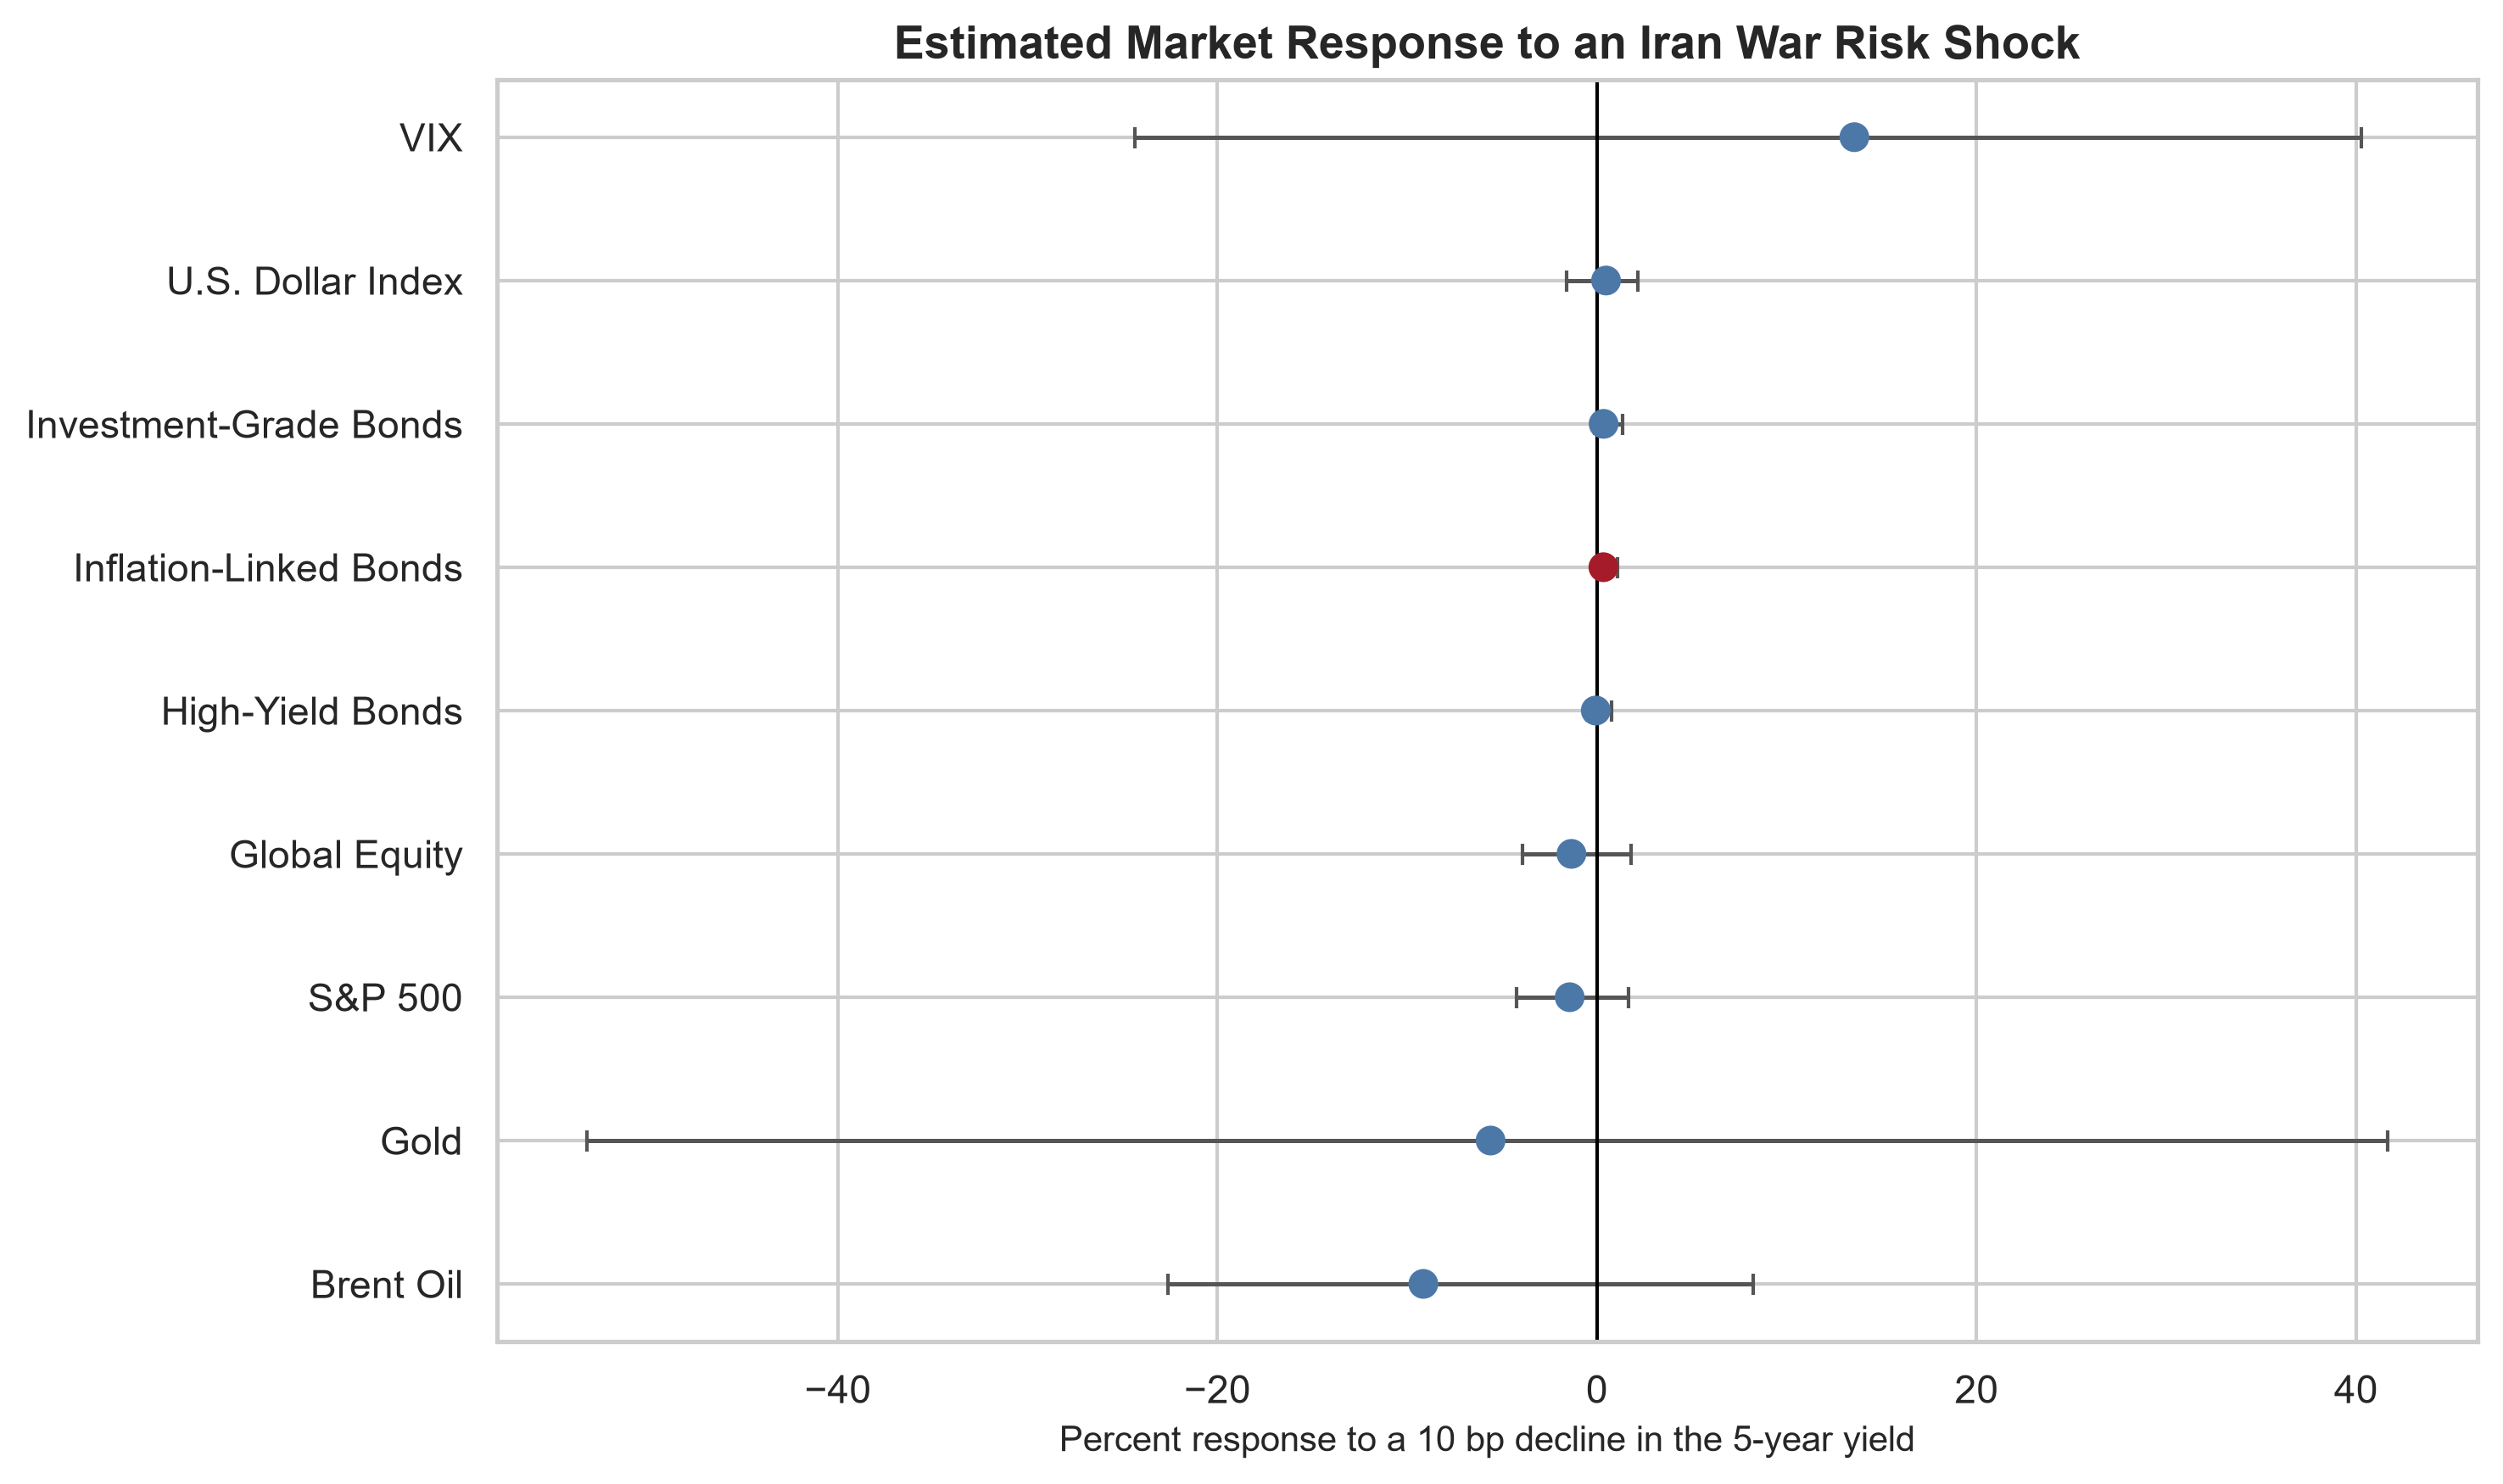

In [11]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/estimated_market_effects.png"
        )
    )
)

#### Table 3: Variance Explained by Iran War Risk

The war-induced increase in variance for variable $$j$$ is:

$$
\widehat{\Delta Var_j}
=
\hat{d}_j^2
\left[
Var_H
\left(
\Delta x_1
\right)
-
Var_L
\left(
\Delta x_1
\right)
\right]
$$

The estimated share of high-news-day variance explained is:

$$
Share_{j,H}
=
\frac{
\widehat{\Delta Var_j}
}{
Var_H
\left(
\Delta x_j
\right)
}
$$

In [12]:
table_3

,Financial Variable,Variance on Low Days,Variance on High Days,Predicted Change in Variance,Explained on High Days (%),Explained in Full Sample (%)
0,5-Year Treasury Yield,0.0014,0.0024,NaN,NaN,NaN
1,10-Year Treasury Yield,0.0012,0.0017,0.0005,27.5300,2.9900
2,S&P 500,0.4069,0.6505,0.2061,31.6900,3.1800
3,Global Equity,0.5769,0.7908,0.1810,22.8800,2.1900
4,Investment-Grade Bonds,0.1066,0.0739,0.0117,15.8800,1.0000
5,High-Yield Bonds,0.0369,0.0388,0.0005,1.2000,0.0800
6,Inflation-Linked Bonds,0.0407,0.0314,0.0110,34.9800,2.4200
7,Brent Oil,3.0477,10.6789,8.3109,77.8300,5.6900
8,Gold,1.7626,11.9256,3.1216,26.1800,8.8700
9,U.S. Dollar Index,0.1396,0.2064,0.0222,10.7500,2.0100


#### Interpretation of Table 3

Iran War Risk accounts for an estimated:

- 27.53 percent of high-news-day variance in the 10-year Treasury yield
- 31.69 percent in the S&P 500
- 22.88 percent in global equities
- 77.83 percent in Brent oil
- 26.18 percent in gold
- 27.62 percent in the VIX

The full-sample percentages are smaller because only 19 of the available market dates are classified as high-news days.

A large variance contribution does not guarantee a reliable directional coefficient. Brent oil is the clearest example. Its high-news-day variance contribution is large, while its estimated directional confidence interval remains wide.

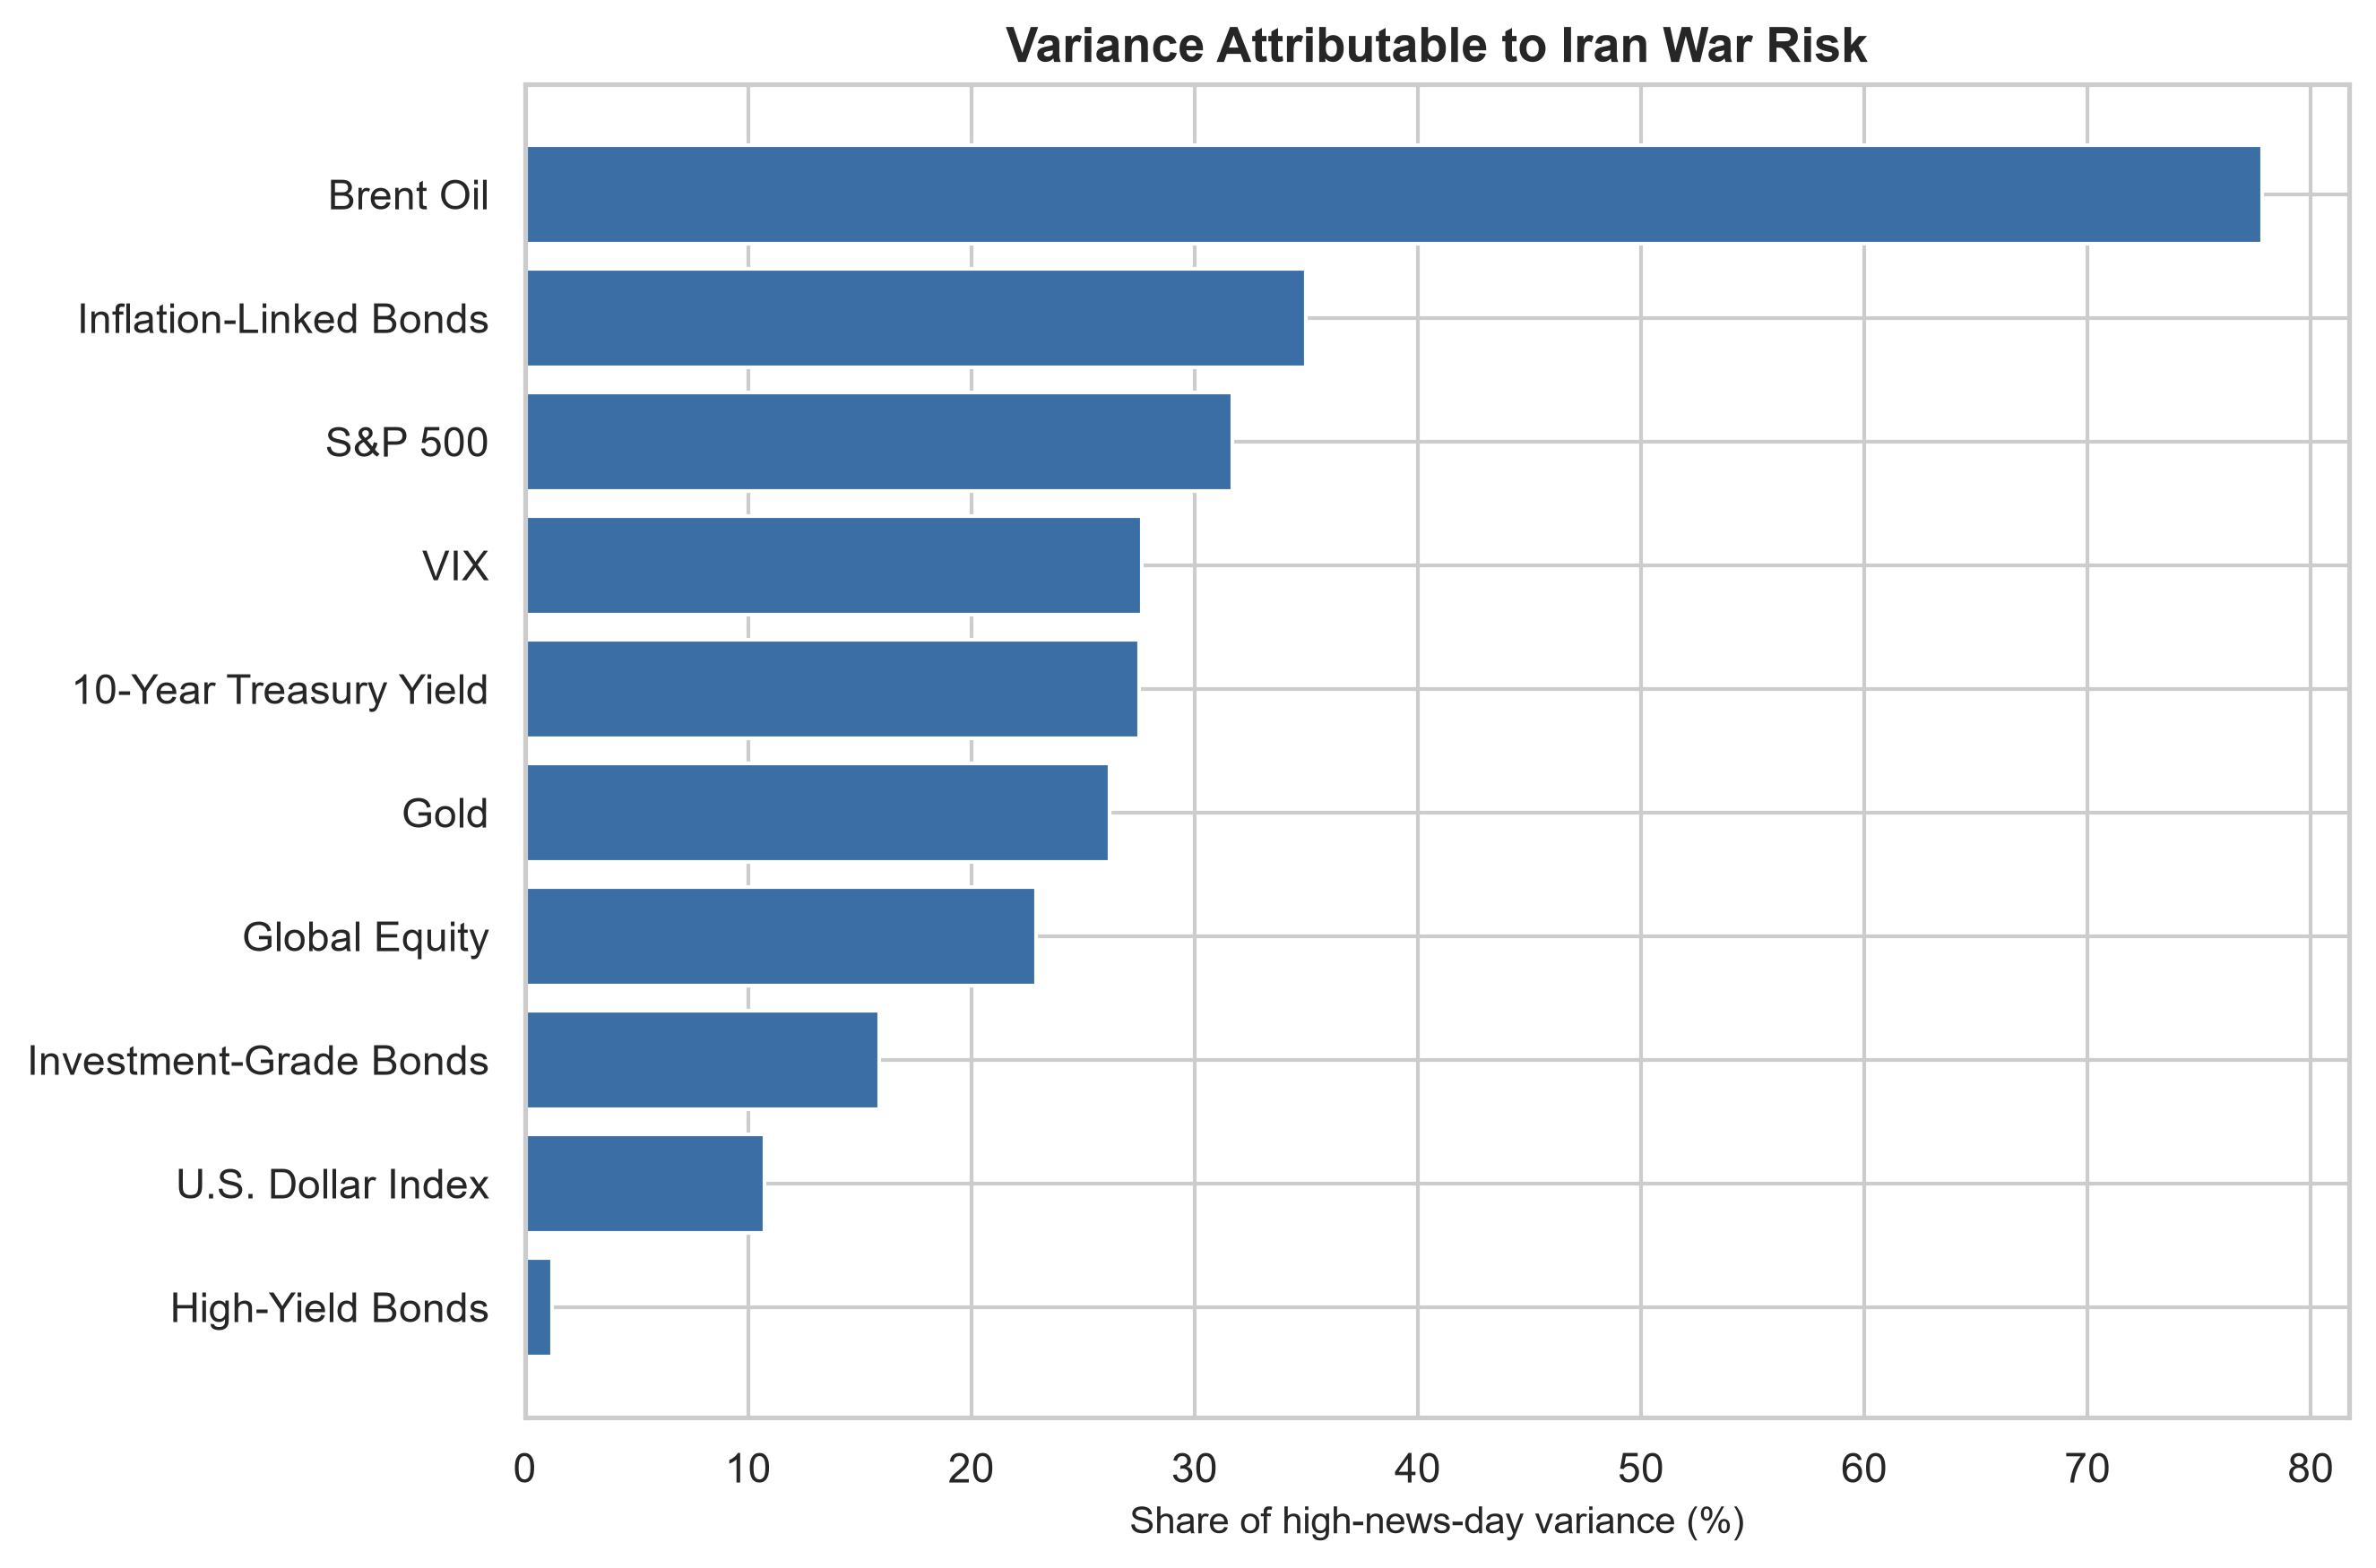

In [13]:
display(
    Image(
        filename=str(
            ROOT
            / "outputs/figures/variance_explained.png"
        )
    )
)

#### Alternative Empirical Method: Direct NLP Regression

Identification through heteroskedasticity is not the only method available for estimating war-risk effects.

A direct NLP approach treats the news-based escalation and intensity scores as observed explanatory variables.

The directional model is:

$$
\Delta x_{j,t}
=
\alpha_j
+
\beta_j SignedRisk_t
+
\varepsilon_{j,t}
$$

The volatility model is:

$$
\left|
\Delta x_{j,t}
\right|
=
\alpha_j
+
\gamma_j RiskIntensity_t
+
\varepsilon_{j,t}
$$

Both NLP variables are standardized. Therefore, each coefficient represents the response to a one-standard-deviation increase in the relevant NLP score.

Heteroskedasticity-consistent HC3 standard errors are used.

#### Table 4A: Direct NLP Directional Regression

In [14]:
direction_table = table_4[
    [
        "label",
        "observations",
        "direction_coefficient",
        "direction_standard_error",
        "direction_p_value",
        "direction_r_squared",
        "direction_significant",
    ]
].copy()

yield_rows = direction_table["label"].isin(
    [
        "5-Year Treasury Yield",
        "10-Year Treasury Yield",
    ]
)

direction_table["Unit"] = "Percent return"
direction_table.loc[yield_rows, "Unit"] = "Basis points"

direction_table.loc[
    yield_rows,
    [
        "direction_coefficient",
        "direction_standard_error",
    ],
] *= 100

direction_table = direction_table.rename(
    columns={
        "label": "Financial Variable",
        "observations": "Observations",
        "direction_coefficient": "Coefficient",
        "direction_standard_error": "HC3 Standard Error",
        "direction_p_value": "P-Value",
        "direction_r_squared": "R-Squared",
        "direction_significant": "Significant at 5%",
    }
)

direction_table.round(4)

,Financial Variable,Observations,Coefficient,HC3 Standard Error,P-Value,R-Squared,Significant at 5%,Unit
0,5-Year Treasury Yield,177,0.6278,0.3080,0.0415,0.0186,True,Basis points
1,10-Year Treasury Yield,177,0.7130,0.2764,0.0099,0.0299,True,Basis points
2,S&P 500,177,-0.0494,0.0654,0.4494,0.0035,False,Percent return
3,Global Equity,177,-0.0394,0.0714,0.5812,0.0018,False,Percent return
4,Investment-Grade Bonds,177,-0.0271,0.0253,0.2834,0.0059,False,Percent return
5,High-Yield Bonds,177,0.0029,0.0180,0.8714,0.0001,False,Percent return
6,Inflation-Linked Bonds,177,-0.0135,0.0174,0.4366,0.0038,False,Percent return
7,Brent Oil,177,0.5437,0.2483,0.0286,0.0190,True,Percent return
8,Gold,177,0.0739,0.1371,0.5901,0.0015,False,Percent return
9,U.S. Dollar Index,177,-0.0324,0.0262,0.2153,0.0090,False,Percent return


A one-standard-deviation increase in escalation language is associated with:

- A 0.63-basis-point increase in the 5-year Treasury yield
- A 0.71-basis-point increase in the 10-year Treasury yield
- A 0.54 percent increase in Brent oil

These three coefficients are statistically significant at the 5 percent level.

The equity coefficients are negative, but they are economically small and statistically insignificant.

#### Table 4B: Direct NLP Intensity and Absolute Market Movement

In [15]:
intensity_table = table_4[
    [
        "label",
        "observations",
        "intensity_coefficient",
        "intensity_standard_error",
        "intensity_p_value",
        "intensity_r_squared",
        "intensity_significant",
    ]
].copy()

yield_rows = intensity_table["label"].isin(
    [
        "5-Year Treasury Yield",
        "10-Year Treasury Yield",
    ]
)

intensity_table["Unit"] = "Absolute percent movement"
intensity_table.loc[
    yield_rows,
    "Unit",
] = "Absolute basis-point movement"

intensity_table.loc[
    yield_rows,
    [
        "intensity_coefficient",
        "intensity_standard_error",
    ],
] *= 100

intensity_table = intensity_table.rename(
    columns={
        "label": "Financial Variable",
        "observations": "Observations",
        "intensity_coefficient": "Coefficient",
        "intensity_standard_error": "HC3 Standard Error",
        "intensity_p_value": "P-Value",
        "intensity_r_squared": "R-Squared",
        "intensity_significant": "Significant at 5%",
    }
)

intensity_table.round(4)

,Financial Variable,Observations,Coefficient,HC3 Standard Error,P-Value,R-Squared,Significant at 5%,Unit
0,5-Year Treasury Yield,177,-0.1230,0.1960,0.5302,0.0020,False,Absolute basis-point movement
1,10-Year Treasury Yield,177,-0.0767,0.1795,0.6692,0.0010,False,Absolute basis-point movement
2,S&P 500,177,0.0233,0.0338,0.4907,0.0019,False,Absolute percent movement
3,Global Equity,177,0.0208,0.0392,0.5957,0.0012,False,Absolute percent movement
4,Investment-Grade Bonds,177,-0.0105,0.0156,0.5010,0.0022,False,Absolute percent movement
5,High-Yield Bonds,177,0.0092,0.0106,0.3832,0.0029,False,Absolute percent movement
6,Inflation-Linked Bonds,177,-0.0159,0.0098,0.1038,0.0129,False,Absolute percent movement
7,Brent Oil,177,0.2892,0.1630,0.0760,0.0117,False,Absolute percent movement
8,Gold,177,0.2877,0.1272,0.0237,0.0453,True,Absolute percent movement
9,U.S. Dollar Index,177,0.0138,0.0179,0.4394,0.0042,False,Absolute percent movement


A one-standard-deviation increase in overall Iran news intensity is associated with a 0.29 percent increase in the absolute daily movement of gold. This result is statistically significant.

Brent oil also shows a positive absolute-movement coefficient of approximately 0.29 percent, with a p-value of 0.076. This provides suggestive, but not 5-percent-significant, evidence that more intense Iran news increases oil-price volatility.

#### Comparison of the Two Empirical Methods

The two approaches answer related but different questions.

| Method | Main Question | Primary Advantage | Primary Limitation |
|---|---|---|---|
| Identification through heteroskedasticity | How do markets load on an unobservable factor whose variance increases on war-news days? | Does not require an exact observed measure of war risk | Requires stable covariance structure and valid regime classification |
| Direct NLP directional regression | How do markets respond to explicitly classified escalation language? | Clear directional interpretation and uses nearly all dates | Treats the NLP score as an accurately measured explanatory variable |
| Direct NLP intensity regression | Does more intense war news increase absolute market movements? | Direct test of the news-volatility relationship | Does not separately identify war news from correlated events |

The methods produce different Treasury interpretations.

The heteroskedasticity model normalizes the latent war-risk shock to a decline in the 5-year Treasury yield. The direct NLP regression instead finds that explicitly classified escalation language is associated with a small increase in 5-year and 10-year yields.

This difference may arise because:

- The latent factor contains dimensions not fully captured by escalation language.
- Iran news may affect expected inflation and energy prices as well as safe-haven demand.
- Headlines can contain both escalation and diplomatic language.
- Other macroeconomic information may occur on the same dates.
- Some heteroskedasticity estimators are weak for particular asset classes.

The direct NLP method produces a clearer oil result. Escalation language is associated with a statistically significant increase in Brent oil prices. The intensity regression also finds a significant increase in gold volatility.

Neither method is uniformly superior. Identification through heteroskedasticity is more appropriate when war risk is treated as an unobservable latent factor. Direct NLP regression is more transparent when the objective is to measure the response to observed escalation language.

#### Other Possible Measures of War Risk

Additional approaches include:

1. **Traditional event studies:** Measure returns within narrow windows around attacks, threats, ceasefires or negotiation announcements.
2. **Geopolitical Risk Index:** Use an established news-based geopolitical-risk measure, although a general index may not isolate Iran.
3. **Prediction-market probabilities:** Use market-implied probabilities of conflict when liquid and clearly defined contracts are available.
4. **Options-implied measures:** Use oil, equity or currency implied volatility and skew as forward-looking measures of tail risk.
5. **Structural VARs:** Estimate dynamic responses using structural restrictions.
6. **Local projections:** Estimate how financial variables respond over multiple horizons.
7. **Principal component analysis:** Extract a common latent factor from a large group of financial variables.

These alternatives require different data and identifying assumptions. The combined NLP and heteroskedasticity framework remains appropriate because NLP identifies the information regimes while the econometric model permits the underlying war-risk factor to remain unobserved.

#### Assumptions

The heteroskedasticity interpretation depends on the following assumptions:

1. Iran War Risk is the primary factor whose variance changes between the selected regimes.
2. Financial-market sensitivities remain stable during the sample.
3. Iran War Risk is approximately orthogonal to other structural shocks.
4. The variance of unrelated shocks remains approximately stable across regimes.
5. High-news dates are not systematically contaminated by monetary-policy or macroeconomic announcements.
6. The relationship between the latent factor and financial variables is approximately linear.

The direct NLP regressions require the signed NLP score to be a meaningful measure of escalation and approximately exogenous to same-day financial shocks.

#### Limitations

The main limitations are:

- Google News RSS limits the number of articles returned for each query.
- NLP is applied to headlines and short RSS descriptions rather than complete articles.
- Mixed headlines can contain both escalation and negotiation language.
- The high-news regime contains only 19 dates.
- The 5-year Treasury yield is used instead of the original paper's 2-year yield.
- Corporate bond and inflation-linked bond ETFs are used as market-traded proxies.
- Major monetary-policy or macroeconomic announcements may overlap with Iran news.
- The heteroskedasticity estimators diverge substantially for some assets.
- Direct NLP regressions have low $ R^2 $ values.
- Statistical significance is limited for several financial variables.
- The results depend on the selected NLP prompts, thresholds and matching procedure.

The estimates should therefore be interpreted as conditional factor sensitivities rather than unrestricted causal effects.

#### Conclusion

NLP analysis identifies a set of 2026 dates with unusually intense Iran-related conflict, nuclear and diplomatic news. Market variance is higher on these dates for nine of the eleven financial variables examined.

Identification through heteroskedasticity finds the strongest evidence in the Treasury market. A latent war-risk shock associated with a 10-basis-point decline in the 5-year Treasury yield produces an estimated 6.94-basis-point decline in the 10-year yield.

The heteroskedasticity estimates also suggest equity declines and a VIX increase, but these responses are not statistically significant. Oil and gold display substantial excess variance, although their directional heteroskedasticity estimates are unstable.

The direct NLP regressions provide a different but complementary result. Explicit escalation language is associated with small increases in Treasury yields and a statistically significant increase in Brent oil. Higher overall news intensity is associated with significantly larger absolute gold-price movements.

The combined evidence indicates that Iran War Risk is relevant to Treasury yields, oil prices and gold volatility. However, the direction and statistical precision of the response vary by methodology and asset class.

The empirical comparison shows why no single measure of war risk is uniformly superior. NLP provides a transparent daily signal, while identification through heteroskedasticity reduces reliance on treating that signal as an error-free measure of the latent geopolitical factor.

#### References

Rigobon, R. (2003). Identification through Heteroskedasticity. *The Review of Economics and Statistics*, 85(4), 777-792.

Rigobon, R., and Sack, B. (2003). The Effects of War Risk on U.S. Financial Markets. *NBER Working Paper No. 9609*.

Caldara, D., and Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194-1225.